In [1]:
import numpy as np
import timeit
import viscid
import os
from scipy.special import iv

argsdict=viscid.argsdict
from scipy.linalg import eig
from scipy.interpolate import interp1d
from scipy.optimize import minimize_scalar
from scipy.signal import find_peaks

import matplotlib.pyplot as plt
from matplotlib.tri import Triangulation

import json
colors = [
    "#1f77b4",
    "#ff7f0e",
    "#2ca02c",
    "#d62728",
    "#9467bd",
    "#8c564b",
    "#e377c2",
    "#7f7f7f",
    "#bcbd22",
    "#17becf",
]

start0=timeit.default_timer()

s=5
s2=0.2
admax=5.0
dfreq=20.0
maxfreq=60
minfreq=15

eta=1E-6
argsdict['dim']=2
argsdict['Nx']=3
argsdict['Ny']=3
argsdict['Nt']=3
argsdict['k1x']=np.pi*s
argsdict['k1y']=0
argsdict['k2x']=-np.pi*s/2
argsdict['k2y']=3**0.5*s/2*np.pi
argsdict['h0']=1.0*s2
argsdict['As']=0.75*s2


num1=52
kxs1=np.arange(1,num1+1)/num1*argsdict['k1x']/2
kys1=np.arange(1,num1+1)/num1*0
num2=30
kxs2=argsdict['k1x']/2+np.arange(1,num2+1)/num2*((2*argsdict['k1x'] + argsdict['k2x'])/3 - argsdict['k1x']/2)
kys2=argsdict['k1y']/2+np.arange(1,num2+1)/num2*((2*argsdict['k1y'] + argsdict['k2y'])/3 - argsdict['k1y']/2)
num3=60
kxs3=np.arange(1,num3)/num3*((2*argsdict['k1x'] + argsdict['k2x'])/3)
kys3=np.arange(1,num3)/num3*((2*argsdict['k1y'] + argsdict['k2y'])/3)
ks=np.concatenate([np.transpose([kxs1[-20:-1:2],kys1[-20:-1:2]]),np.transpose([kxs2[::2],kys2[::2]]),np.transpose([kxs3[-2:-16:-2],kys3[-2:-16:-2]])])

argsdict['rho']=1.0
argsdict['sigma']=20
argsdict['mu']=0.2

Fluid depth in cm

In [2]:
argsdict['h0']

0.2

Substrate amplitude in cm

In [3]:
argsdict['As']

0.15000000000000002

Substrate wavelength in cm

In [4]:
2*np.pi/argsdict['k1x']

0.4

### Dispersion relations and band gap for the inviscid problem

In [5]:
start=timeit.default_timer()

argsdict['As']=0.0
evalssweep1=[]
revecssweep1=[]
levecssweep1=[]
for i in range(num1):
    argsdict['kx']=kxs1[i]
    argsdict['ky']=kys1[i]
    F,G=viscid.inviscid_mat_undriven(argsdict)
    evals,revecs,levecs=eig(F,G,right=True,left=True)
    evalssweep1=evalssweep1+[evals]
    revecssweep1=revecssweep1+[revecs]
    levecssweep1=levecssweep1+[levecs]
stop=timeit.default_timer()
print(stop-start)

start=timeit.default_timer()
evalssweep2=[]
revecssweep2=[]
levecssweep2=[]
for i in range(num2-1):
    argsdict['kx']=kxs2[i]
    argsdict['ky']=kys2[i]
    F,G=viscid.inviscid_mat_undriven(argsdict)
    evals,revecs,levecs=eig(F,G,right=True,left=True)
    evalssweep2=evalssweep2+[evals]
    revecssweep2=revecssweep2+[revecs]
    levecssweep2=levecssweep2+[levecs]
    
stop=timeit.default_timer()
print(stop-start)

start=timeit.default_timer()
evalssweep3=[]
revecssweep3=[]
levecssweep3=[]
for i in range(num3-1):
    argsdict['kx']=kxs3[i]
    argsdict['ky']=kys3[i]
    F,G=viscid.inviscid_mat_undriven(argsdict)
    evals,revecs,levecs=eig(F,G,right=True,left=True)
    evalssweep3=evalssweep3+[evals]
    revecssweep3=revecssweep3+[revecs]
    levecssweep3=levecssweep3+[levecs]

stop=timeit.default_timer()
print(stop-start)

vals1=np.sort(np.real((np.array(evalssweep1))**0.5/(2*np.pi)),axis=1)
vals2=np.sort(np.real((np.array(evalssweep2))**0.5/(2*np.pi)),axis=1)
vals3=np.flip(np.sort(np.real((np.array(evalssweep3))**0.5/(2*np.pi)),axis=1),axis=0)

argsdict['As']=0.75*s2
evalssweep12=[]
revecssweep12=[]
levecssweep12=[]
for i in range(len(kxs1)):
    argsdict['kx']=kxs1[i]
    argsdict['ky']=kys1[i]
    F,G=viscid.inviscid_mat_undriven(argsdict)
    evals,revecs,levecs=eig(F,G,right=True,left=True)
    evalssweep12=evalssweep12+[evals]
    revecssweep12=revecssweep12+[revecs]
    levecssweep12=levecssweep12+[np.conjugate(levecs)]
    
stop=timeit.default_timer()
print(stop-start)

start=timeit.default_timer()
evalssweep22=[]
revecssweep22=[]
levecssweep22=[]
for i in range(len(kxs2)):
    argsdict['kx']=kxs2[i]
    argsdict['ky']=kys2[i]
    F,G=viscid.inviscid_mat_undriven(argsdict)
    evals,revecs,levecs=eig(F,G,right=True,left=True)
    evalssweep22=evalssweep22+[evals]
    revecssweep22=revecssweep22+[revecs]
    levecssweep22=levecssweep22+[np.conjugate(levecs)]
    
stop=timeit.default_timer()
print(stop-start)

start=timeit.default_timer()
evalssweep32=[]
revecssweep32=[]
levecssweep32=[]
for i in range(len(kxs3)):
    argsdict['kx']=kxs3[i]
    argsdict['ky']=kys3[i]
    F,G=viscid.inviscid_mat_undriven(argsdict)
    evals,revecs,levecs=eig(F,G,right=True,left=True)
    evalssweep32=evalssweep32+[evals]
    revecssweep32=revecssweep32+[revecs]
    levecssweep32=levecssweep32+[np.conjugate(levecs)]

stop=timeit.default_timer()
print(stop-start)

vals12=np.sort(np.real((np.array(evalssweep12))**0.5/(2*np.pi)),axis=1)
vals22=np.sort(np.real((np.array(evalssweep22))**0.5/(2*np.pi)),axis=1)
vals32=np.flip(np.sort(np.real((np.array(evalssweep32))**0.5/(2*np.pi)),axis=1),axis=0)


0.1355873660000002
0.0466208650000004
0.10974751000000005
0.37841557100000056
0.15423304800000004
0.3136895439999998


47.34312040782576 40.195297065149234
[40.19529707 40.19529707]
45.53654361811111 39.630644769428805
[37.17526314 39.63064477]


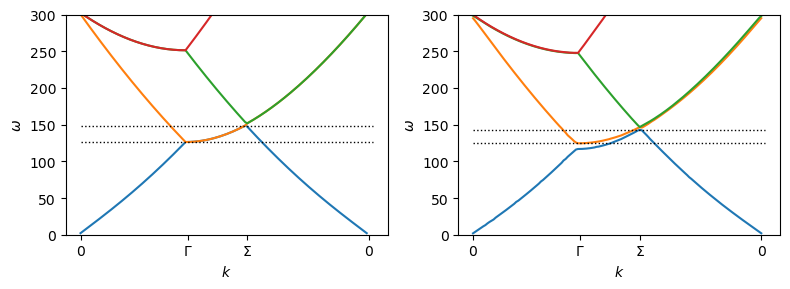

In [6]:
plt.subplots(1,2,figsize=(8,3))

plt.subplot(1,2,1)

plt.ylim(0,300)
plt.plot(np.concatenate([vals1,vals2,vals3])*2*np.pi)
plt.plot([0,num1+num2+num3],[np.max(np.concatenate([vals1,vals2,vals3])[:,0]*2*np.pi),np.max(np.concatenate([vals1,vals2,vals3])[:,0]*2*np.pi)],ls=':',lw=1,c='black')
plt.plot([0,num1+num2+num3],[np.min(np.concatenate([vals1,vals2,vals3])[:,1]*2*np.pi),np.min(np.concatenate([vals1,vals2,vals3])[:,1]*2*np.pi)],ls=':',lw=1,c='black')

print(2*np.max(np.concatenate([vals1,vals2,vals3])[:,0]),2*np.min(np.concatenate([vals1,vals2,vals3])[:,1]))
print(vals1[-1][:2]*2)
plt.xticks([0,num1,num1+num2-1,num1+num2+num3-2],['0','$\Gamma$','$\Sigma$','0'])
plt.xlabel('$k$')
plt.ylabel('$\omega$')

plt.subplot(1,2,2)
plt.ylim(0,300)
plt.plot(np.concatenate([vals12,vals22,vals32])*2*np.pi)
plt.plot([0,num1+num2+num3],[np.max(np.concatenate([vals12,vals22,vals32])[:,0]*2*np.pi),np.max(np.concatenate([vals12,vals22,vals32])[:,0]*2*np.pi)],ls=':',lw=1,c='black')
plt.plot([0,num1+num2+num3],[np.min(np.concatenate([vals12,vals22,vals32])[:,1]*2*np.pi),np.min(np.concatenate([vals12,vals22,vals32])[:,1]*2*np.pi)],ls=':',lw=1,c='black')

print(2*np.max(np.concatenate([vals12,vals22,vals32])[:,0]),2*np.min(np.concatenate([vals12,vals22,vals32])[:,1]))
print(vals12[-1][:2]*2)
plt.xticks([0,num1,num1+num2-1,num1+num2+num3-2],['0','$\Gamma$','$\Sigma$','0'])
plt.xlabel('$k$')
plt.ylabel('$\omega$')


plt.tight_layout()
plt.savefig('plots/dispersion_experiment.pdf')
plt.show()

47.34312040782576 40.195297065149234
[40.19529707 40.19529707]
45.53654361811111 39.630644769428805
[37.17526314 39.63064477]


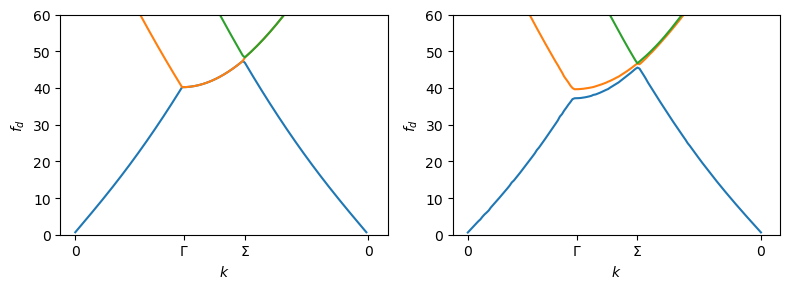

In [7]:
plt.subplots(1,2,figsize=(8,3))

plt.subplot(1,2,1)

plt.ylim(0,60)
plt.plot(np.concatenate([vals1,vals2,vals3])*2)
plt.plot([0,num1+num2+num3],[np.max(np.concatenate([vals1,vals2,vals3])[:,0]*2*np.pi),np.max(np.concatenate([vals1,vals2,vals3])[:,0]*2*np.pi)],ls=':',lw=1,c='black')
plt.plot([0,num1+num2+num3],[np.min(np.concatenate([vals1,vals2,vals3])[:,1]*2*np.pi),np.min(np.concatenate([vals1,vals2,vals3])[:,1]*2*np.pi)],ls=':',lw=1,c='black')

print(2*np.max(np.concatenate([vals1,vals2,vals3])[:,0]),2*np.min(np.concatenate([vals1,vals2,vals3])[:,1]))
print(vals1[-1][:2]*2)
plt.xticks([0,num1,num1+num2-1,num1+num2+num3-2],['0','$\Gamma$','$\Sigma$','0'])
plt.xlabel('$k$')
plt.ylabel('$f_d$')

plt.subplot(1,2,2)
plt.ylim(0,60)
plt.plot(np.concatenate([vals12,vals22,vals32])*2)
plt.plot([0,num1+num2+num3],[np.max(np.concatenate([vals12,vals22,vals32])[:,0]*2*np.pi),np.max(np.concatenate([vals12,vals22,vals32])[:,0]*2*np.pi)],ls=':',lw=1,c='black')
plt.plot([0,num1+num2+num3],[np.min(np.concatenate([vals12,vals22,vals32])[:,1]*2*np.pi),np.min(np.concatenate([vals12,vals22,vals32])[:,1]*2*np.pi)],ls=':',lw=1,c='black')

print(2*np.max(np.concatenate([vals12,vals22,vals32])[:,0]),2*np.min(np.concatenate([vals12,vals22,vals32])[:,1]))
print(vals12[-1][:2]*2)
plt.xticks([0,num1,num1+num2-1,num1+num2+num3-2],['0','$\Gamma$','$\Sigma$','0'])
plt.xlabel('$k$')
plt.ylabel('$f_d$')


plt.tight_layout()
plt.savefig('plots/dispersion_experiment.pdf')
plt.show()

### Viscid instability boundary

In [8]:
argsdict['ad']=0
argsdict['kx']=ks[0][0]
argsdict['ky']=ks[0][1]
argsdict['verbose']=1
argsdict['dsmin']=1E-4


def mat0(omega,argsdict):
        E,F=viscid.viscid_mat2d(omega,argsdict)
        shape=E.shape
        E_shaped=E.reshape((3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1,3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1))
        F_shaped=F.reshape((3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1,3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1))

        return (np.tensordot(E_shaped,argsdict['preconditioner'],axes=argsdict['precondition_axes'])-argsdict['ad']*np.tensordot(F_shaped,argsdict['preconditioner'],axes=argsdict['precondition_axes'])).transpose(argsdict['precondition_order']).reshape(shape).T
def mat3(omega,argsdict):
        E,F=viscid.viscid_mat2d(omega,argsdict)
        shape=E.shape
        E_shaped=E.reshape((3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1,3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1))
        F_shaped=F.reshape((3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1,3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1))

        return (-np.tensordot(F_shaped,argsdict['preconditioner'],axes=argsdict['precondition_axes'])).transpose(argsdict['precondition_order']).reshape(shape).T

def mat(ad,argsdict):
    E,F=viscid.viscid_mat2d(2*np.pi*argsdict['freq']/2,argsdict)
    shape=E.shape
    E_shaped=E.reshape((3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1,3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1))
    F_shaped=F.reshape((3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1,3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1))

    return (np.tensordot(E_shaped,argsdict['preconditioner'],axes=argsdict['precondition_axes'])-ad*np.tensordot(F_shaped,argsdict['preconditioner'],axes=argsdict['precondition_axes'])).transpose(argsdict['precondition_order']).reshape(shape).T
def mat2(ad,argsdict):
    E,F=viscid.viscid_mat2d(2*np.pi*argsdict['freq']/2,argsdict)
    shape=E.shape
    E_shaped=E.reshape((3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1,3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1))
    F_shaped=F.reshape((3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1,3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1))

    return (-np.tensordot(F_shaped,argsdict['preconditioner'],axes=argsdict['precondition_axes'])).transpose(argsdict['precondition_order']).reshape(shape).T

Find the starting critical eigenvalues and eigenvectors by continuing the driving amplitude and finding the critical value at fixed frequency and wavenumber

In [10]:
freq0s

array([19.95381499, 51.55579572])

In [11]:
argsdict['kx']=ks[0][0]
argsdict['ky']=ks[0][1]
F,G=viscid.inviscid_mat_undriven(argsdict)
evals,revecs,levecs=eig(F,G,right=True,left=True)
order=np.argsort(np.real(evals))
freq0s=0.9*np.real(evals[order[:2]]**0.5/(2*np.pi/2)) #reduce the frequency a bit relative to inviscid case
print(freq0s)

argsdict['verbose']=3
argsdict['lambdamax']=np.inf
ds=1E-1
dsmax=1E1
argsdict['itmax']=10
argsdict['ds']=ds
argsdict['dsmax']=dsmax
argsdict['dsmin']=1E-4
argsdict['epsl']=1E-2
argsdict['epsu']=1E-2
argsdict['epstp']=1E0
argsdict['thmu']=1E1
argsdict['thl']=1E-1
argsdict['thu']=1E-4

ads01=[]
ads02=[]
ads03=[]
vs01=[]
vs02=[]
vs03=[]
ws01=[]
ws02=[]
ws03=[]
omegas01=[]
omegas02=[]
omegas03=[]
dirs01=[]

load=True
overwrite=True

start=timeit.default_timer()
for j in range(2):
    if not os.path.exists('data/experiment/%iads01.npy'%(j)) or not load:
        omega=evals[order[j]]**0.5+1j*0
        E,F=viscid.viscid_mat2d(omega,argsdict)

        v=np.zeros((3,(2*argsdict['Nt']+1),(2*argsdict['Nx']+1),(2*argsdict['Ny']+1)),np.complex128)
        w=np.zeros((3,(2*argsdict['Nt']+1),(2*argsdict['Nx']+1),(2*argsdict['Ny']+1)),np.complex128)
        v[2,argsdict['Nt']]=revecs[:,order[j]].reshape((2*argsdict['Nx']+1,2*argsdict['Ny']+1))
        w[2,argsdict['Nt']]=levecs[:,order[j]].reshape((2*argsdict['Nx']+1,2*argsdict['Ny']+1))
        v=v.ravel()
        w=w.ravel()

        freq0=freq0s[j]
        omega=evals[order[j]]**0.5+1j*0
        argsdict['freq']=freq0
        argsdict['ad']=0

        lps,ls,mps,ms,nps,ns=viscid.makeindices(argsdict)
        kappax = (argsdict['kx'] + argsdict['k1x']*ms + argsdict['k2x']*ns)
        kappay = (argsdict['ky'] + argsdict['k1y']*ms + argsdict['k2y']*ns)
        kappa = (kappax**2+kappay**2)**0.5
        kappapx = (argsdict['kx'] + argsdict['k1x']*mps + argsdict['k2x']*nps)
        kappapy = (argsdict['ky'] + argsdict['k1y']*mps + argsdict['k2y']*nps)
        S = (- np.exp(-kappa*argsdict['h0']) * iv(ms-mps, kappa*argsdict['As']*0.5) * iv(ns-nps, kappa*argsdict['As']*0.5) + np.exp(kappa*argsdict['h0']) * iv(ms-mps, -kappa*argsdict['As']*0.5) * iv(ns-nps, -kappa*argsdict['As']*0.5))
        C = (np.exp(-kappa*argsdict['h0']) * iv(ms-mps, kappa*argsdict['As']*0.5) * iv(ns-nps, kappa*argsdict['As']*0.5) + np.exp(kappa*argsdict['h0']) * iv(ms-mps, -kappa*argsdict['As']*0.5) * iv(ns-nps, -kappa*argsdict['As']*0.5))

        #right preconditioner
        shape_flat=((2*argsdict['Nx']+1)*(2*argsdict['Ny']+1),(2*argsdict['Nx']+1)*(2*argsdict['Ny']+1))
        shape2=((2*argsdict['Nx']+1),(2*argsdict['Ny']+1),(2*argsdict['Nx']+1),(2*argsdict['Ny']+1))
        A2=argsdict['g']*(argsdict['rho']**2*(kappax*kappapx+kappay*kappapy)/kappa*S)
        argsdict['preconditioner']=np.linalg.inv(A2.reshape(shape_flat)).reshape(shape2)

        argsdict['precondition_axes']=((6,7),(0,1))
        argsdict['precondition_order']=(0,1,2,3,4,5,6,7)


        #starting frequency and driving
        omegas,vs,ws=viscid.rayleigh_mat(omega,v,np.conjugate(w),mat0,argsdict)
        omega0=omegas[-1]
        v0=vs[-1]
        w0=ws[-1]
        print(freq0,omegas[-1]/np.pi)
        argsdict['par']='ad'
        argsdict['pari']=0
        argsdict['parf']=admax
        argsdict['ds']=ds/10
        argsdict['dsmax']=dsmax
        omegas,vs,ws,pars,dirs,dss=viscid.pseudocont(omega0,v0,w0,mat0,argsdict,mat3=mat3, real=1)
        omegas01=omegas01+[omegas]
        vs01=vs01+[vs]
        ws01=ws01+[ws]
        ads01=ads01+[pars]
        dirs01=dirs01+[dirs]
        plt.plot(ads01[j],np.real(omegas01[j])/(2*np.pi*freq0s[j]),c=colors[0], marker='o', ms=5)
        plt.show()
        
        ind=np.argmax(pars)
        fomega=interp1d(np.arange(len(omegas)),omegas,kind='cubic')
        fv=interp1d(np.arange(len(omegas)),np.array(vs).T,kind='cubic')
        fw=interp1d(np.arange(len(omegas)),np.array(ws).T,kind='cubic')
        fpar=interp1d(np.arange(len(omegas)),pars,kind='cubic')
        fdir=interp1d(np.arange(len(omegas)),np.array(dirs).T,kind='cubic')

        if ind<len(pars)-3:
            if pars[ind-2]<pars[ind] and pars[ind+2]<pars[ind]:
                find=minimize_scalar(lambda x: -fpar(x),bracket=(ind-1,ind+1)).x
            else:
                find=minimize_scalar(lambda x: fpar(x),bracket=(ind-1,ind+1)).x
        else:
            find=ind
            
        omega0=complex(fomega(find))
        v0=fv(find)
        w0=fw(find)
        dir0=fdir(find)
        s=3*(2*argsdict['Nt']+1)*(2*argsdict['Nx']+1)*(2*argsdict['Ny']+1)
        newdir=np.zeros(dir0.shape)
        newdir[:s]=dir0[s:2*s]
        newdir[s:2*s]=-dir0[:s]
        newdir[2*s]=dir0[2*s+1]
        newdir[2*s+1]=-dir0[2*s]
        newdir[2*s+2]=2*dir0[2*s+2]
        dir0=newdir
        argsdict['ad']=fpar(find)
        print(ind,argsdict['ad'],omega0)
        argsdict['ds']=ds
        argsdict['dsmax']=dsmax
        omegas,vs,ws,pars,dirs,dss=viscid.pseudocont(omega0,v0,w0,mat0,argsdict,mat3=mat3,dir=dir0,real=-1)
        omegas02=omegas02+[omegas]
        vs02=vs02+[vs]
        ws02=ws02+[ws]
        ads02=ads02+[pars]
        argsdict['ds']=-ds*10
        argsdict['ad']=fpar(find)
        omegas,vs,ws,pars,dirs,dss=viscid.pseudocont(omega0,v0,w0,mat0,argsdict,mat3=mat3,dir=dir0,real=-1)
        argsdict['ds']=-argsdict['ds']
        omegas03=omegas03+[omegas]
        vs03=vs03+[vs]
        ws03=ws03+[ws]
        ads03=ads03+[pars]

        if overwrite:
            np.save('data/experiment/%iomegas01.npy'%(j),omegas01[j])
            np.save('data/experiment/%iads01.npy'%(j),ads01[j])
            np.save('data/experiment/%ivs01.npy'%(j),vs01[j])
            np.save('data/experiment/%iws01.npy'%(j),ws01[j])

            np.save('data/experiment/%iomegas02.npy'%(j),omegas02[j])
            np.save('data/experiment/%iads02.npy'%(j),ads02[j])
            np.save('data/experiment/%ivs02.npy'%(j),vs02[j])
            np.save('data/experiment/%iws02.npy'%(j),ws02[j])

            np.save('data/experiment/%iomegas03.npy'%(j),omegas03[j])
            np.save('data/experiment/%iads03.npy'%(j),ads03[j])
            np.save('data/experiment/%ivs03.npy'%(j),vs03[j])
            np.save('data/experiment/%iws03.npy'%(j),ws03[j])
    else:
        omegas01=omegas01+[np.load('data/experiment/%iomegas01.npy'%(j))]
        ads01=ads01+[np.load('data/experiment/%iads01.npy'%(j))]
        vs01=vs01+[np.load('data/experiment/%ivs01.npy'%(j))]
        ws01=ws01+[np.load('data/experiment/%iws01.npy'%(j))]

        omegas02=omegas02+[np.load('data/experiment/%iomegas02.npy'%(j))]
        ads02=ads02+[np.load('data/experiment/%iads02.npy'%(j))]
        vs02=vs02+[np.load('data/experiment/%ivs02.npy'%(j))]
        ws02=ws02+[np.load('data/experiment/%iws02.npy'%(j))]

        omegas03=omegas03+[np.load('data/experiment/%iomegas03.npy'%(j))]
        ads03=ads03+[np.load('data/experiment/%iads03.npy'%(j))]
        vs03=vs03+[np.load('data/experiment/%ivs03.npy'%(j))]
        ws03=ws03+[np.load('data/experiment/%iws03.npy'%(j))]


stop=timeit.default_timer()
print(stop-start)

[19.95381499 51.55579572]
0.010165239999999187


n=0 dv=2.361909e-02 dw=8.229557e-02 dl=1.917938e-01
n=1 dv=1.661758e-02 dw=7.963947e-03 dl=3.509385e-01
n=2 dv=1.570970e-02 dw=4.822237e-03 dl=1.682452e-01
n=3 dv=5.206300e-03 dw=1.439454e-03 dl=8.349081e-02
n=4 dv=6.365713e-04 dw=2.158853e-04 dl=3.955290e-03
n=0 dv=2.550248e-03 dw=9.495117e-03 dl=6.409922e-02
n=1 dv=8.451260e-05 dw=1.561848e-03 dl=3.248391e-04
n=2 dv=2.739795e-04 dw=1.962809e-03 dl=8.197826e-08
n=3 dv=2.153952e-04 dw=2.555793e-03 dl=1.918443e-07
n=4 dv=1.691407e-04 dw=5.237859e-04 dl=1.979738e-07


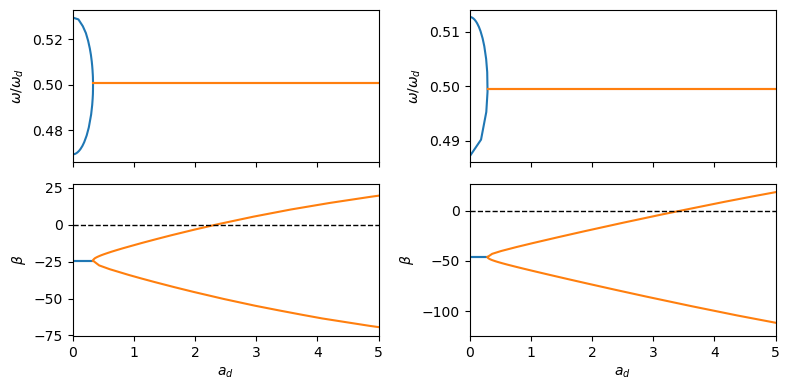

[(2.3309878721469555+3.601958697910419e-05j), (3.4485386590222693+2.653382454326284e-07j)]


In [12]:
ad0s=[]
vn0s=[]
wn0s=[]
argsdict['epsu']=1E-3

for j in range(2):
    freq0=freq0s[j]
    omega=evals[order[j]]**0.5+1j*0
    argsdict['freq']=freq0
    argsdict['ad']=0

    lps,ls,mps,ms,nps,ns=viscid.makeindices(argsdict)
    kappax = (argsdict['kx'] + argsdict['k1x']*ms + argsdict['k2x']*ns)
    kappay = (argsdict['ky'] + argsdict['k1y']*ms + argsdict['k2y']*ns)
    kappa = (kappax**2+kappay**2)**0.5
    kappapx = (argsdict['kx'] + argsdict['k1x']*mps + argsdict['k2x']*nps)
    kappapy = (argsdict['ky'] + argsdict['k1y']*mps + argsdict['k2y']*nps)
    S = (- np.exp(-kappa*argsdict['h0']) * iv(ms-mps, kappa*argsdict['As']*0.5) * iv(ns-nps, kappa*argsdict['As']*0.5) + np.exp(kappa*argsdict['h0']) * iv(ms-mps, -kappa*argsdict['As']*0.5) * iv(ns-nps, -kappa*argsdict['As']*0.5))
    C = (np.exp(-kappa*argsdict['h0']) * iv(ms-mps, kappa*argsdict['As']*0.5) * iv(ns-nps, kappa*argsdict['As']*0.5) + np.exp(kappa*argsdict['h0']) * iv(ms-mps, -kappa*argsdict['As']*0.5) * iv(ns-nps, -kappa*argsdict['As']*0.5))

    #right preconditioner
    shape_flat=((2*argsdict['Nx']+1)*(2*argsdict['Ny']+1),(2*argsdict['Nx']+1)*(2*argsdict['Ny']+1))
    shape2=((2*argsdict['Nx']+1),(2*argsdict['Ny']+1),(2*argsdict['Nx']+1),(2*argsdict['Ny']+1))
    A2=argsdict['g']*(argsdict['rho']**2*(kappax*kappapx+kappay*kappapy)/kappa*S)
    argsdict['preconditioner']=np.linalg.inv(A2.reshape(shape_flat)).reshape(shape2)

    argsdict['precondition_axes']=((6,7),(0,1))
    argsdict['precondition_order']=(0,1,2,3,4,5,6,7)
        
    argsdict['freq']=freq0s[j]
    ind=np.argmin(np.abs(np.imag(omegas03[j])))
    ad0=ads03[j][ind]
    v0=vs03[j][ind]
    w0=ws03[j][ind]
    if np.min(omegas02[j])<0:
        ind=np.argmin(np.abs(np.imag(omegas02[j])))
        ad0=ads02[j][ind]
        v0=vs02[j][ind]
        w0=ws02[j][ind]
    ads,vs,ws=viscid.rayleigh_mat(ad0,v0,w0,mat,argsdict,mat2)
    ad0s=ad0s+[ads[-1]]
    vn0s=vn0s+[vs[-1]]
    wn0s=wn0s+[ws[-1]]
    
plt.subplots(2,2,figsize=(8,4))

for j in range(2):
    plt.subplot(2,2,j+1)
    plt.plot(ads01[j],np.real(omegas01[j])/(2*np.pi*freq0s[j]),c=colors[0])
    plt.plot(ads02[j],np.real(omegas02[j])/(2*np.pi*freq0s[j]),c=colors[1])
    plt.plot(ads03[j],np.real(omegas03[j])/(2*np.pi*freq0s[j]),c=colors[1])
    plt.xlim(0,admax)

    plt.gca().set_xticks(plt.gca().get_xticks(),['']*len(plt.gca().get_xticks()))
    plt.ylabel(r'$\omega/\omega_d$')

    plt.subplot(2,2,j+3)
    plt.plot(ads01[j],-np.imag(omegas01[j]),c=colors[0])
    plt.plot(ads02[j],-np.imag(omegas02[j]),c=colors[1])
    plt.plot(ads03[j],-np.imag(omegas03[j]),c=colors[1])
    plt.plot([0,admax],[0,0],ls='--',color='black',lw=1)
    plt.ylabel(r'$\beta$')
    plt.xlabel('$a_d$')
    plt.xlim(0,admax)


plt.tight_layout()
plt.show()
print(ad0s)


[[4.98425758 0.        ]
 [5.28633379 0.        ]
 [5.58841001 0.        ]
 [5.89048623 0.        ]
 [6.19256244 0.        ]
 [6.49463866 0.        ]
 [6.79671488 0.        ]
 [7.09879109 0.        ]
 [7.40086731 0.        ]
 [7.70294353 0.        ]
 [7.85398163 0.15114995]
 [7.85398163 0.45344984]
 [7.85398163 0.75574974]
 [7.85398163 1.05804963]
 [7.85398163 1.36034952]
 [7.85398163 1.66264942]
 [7.85398163 1.96494931]
 [7.85398163 2.26724921]
 [7.85398163 2.5695491 ]
 [7.85398163 2.87184899]
 [7.85398163 3.17414889]
 [7.85398163 3.47644878]
 [7.85398163 3.77874868]
 [7.85398163 4.08104857]
 [7.85398163 4.38334846]
 [7.59218225 4.38334846]
 [7.33038286 4.23219852]
 [7.06858347 4.08104857]
 [6.80678408 3.92989862]
 [6.54498469 3.77874868]
 [6.28318531 3.62759873]
 [6.02138592 3.47644878]]
32
0 19.953814994580355 4.984257575406883 0.0


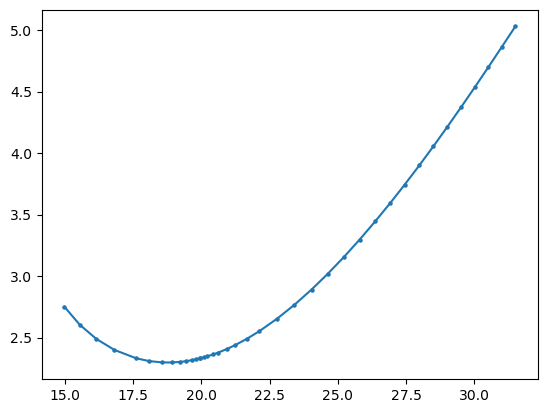

14.97906481207815 31.50033980342872 18.90560736362685 (2.29753352882918-0.003425966608040979j)
0.19933760100001052
1 18.90560736362685 5.28633379209821 0.0


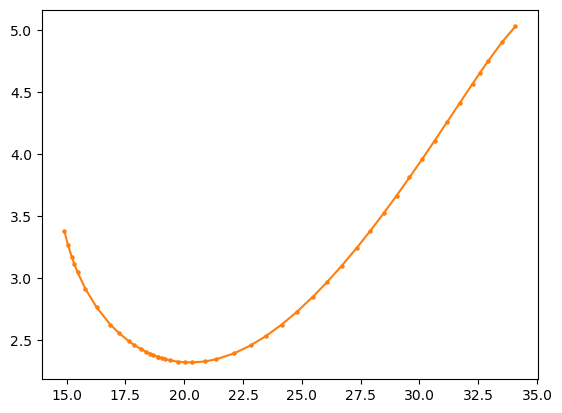

14.906534525549866 34.072728211812354 20.349325906764566 (2.3164615059367546+0.005082783399076162j)
0.41225105300000564
2 20.349325906764566 5.588410008789536 0.0


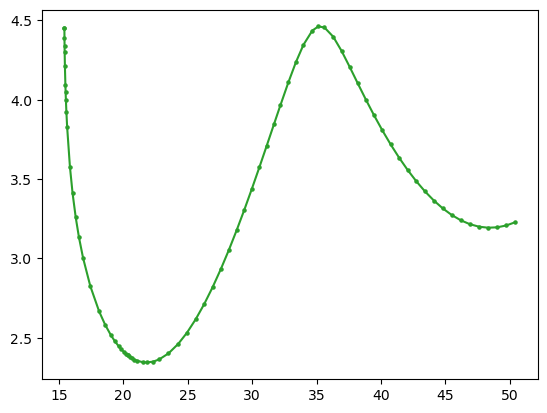

15.423329405507609 50.436686202365635 21.825590681750317 (2.3441723755910053+0.0036623576109200808j)
0.6336940409999983
3 21.825590681750317 5.890486225480862 0.0


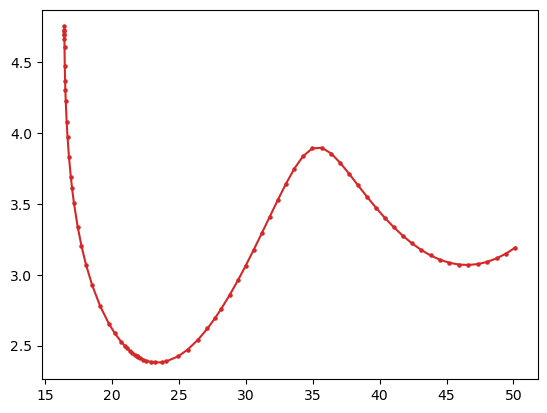

16.42767471861692 50.14352501604044 23.215831976431733 (2.3804063087967915+0.001254556174498118j)
0.813352504000008
4 23.215831976431733 6.192562442172188 0.0


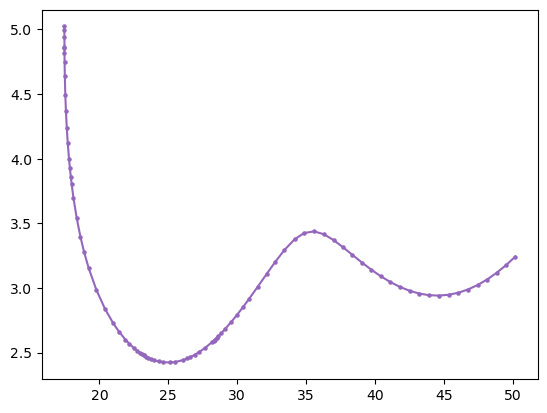

17.452355788425553 50.200063145130265 25.119462396350183 (2.4228808390363574-0.012339867030809942j)
0.9516908430000086
5 25.119462396350183 6.494638658863514 0.0


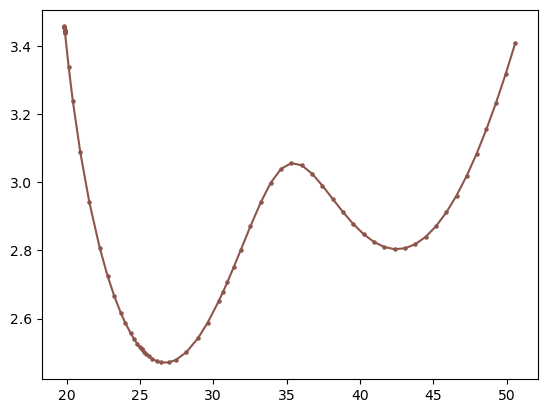

19.855240392059464 50.57678686415871 26.46198519835034 (2.471494389763042+0.021925187340917453j)
1.0865195970000059
6 26.46198519835034 6.796714875554841 0.0


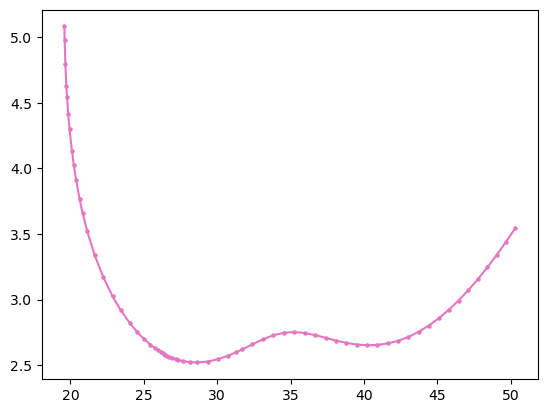

19.58504700084936 50.31984475612025 28.63512023977406 (2.5194850433396003+0.001890637420970879j)
1.2174122620000105
7 28.63512023977406 7.0987910922461674 0.0


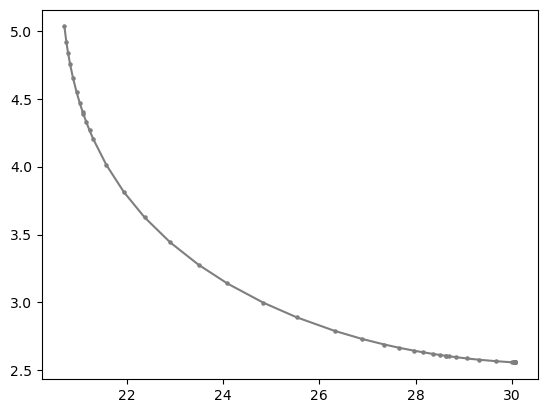

20.706777958417593 30.070307378044973 30.060934743661154 (2.5581374300395705+0.035588990635568404j)
1.3579747630000014
8 30.060934743661154 7.400867308937493 0.0


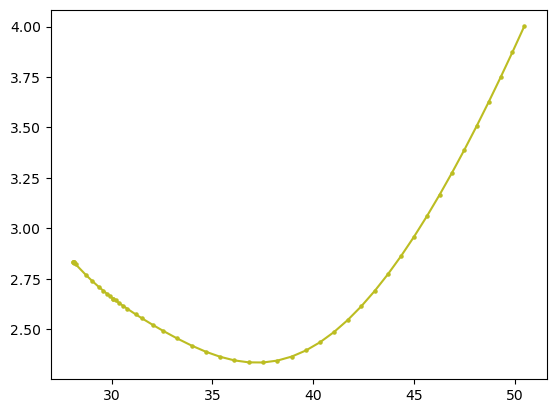

28.088505644536387 50.48054369570327 37.513056260371975 (2.3350623621147877+0.025346637196819274j)
1.4816201220000096
9 37.513056260371975 7.702943525628819 0.0


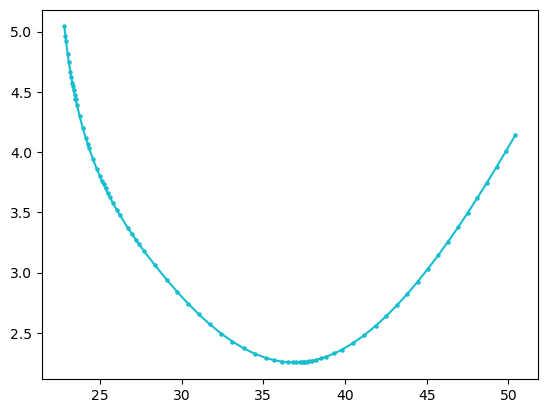

22.83460283677685 50.41847489189776 36.80403705233625 (2.253615319750295-0.00280875121520728j)
1.7137948840000092
10 36.80403705233625 7.853981633974483 0.15114994701951814


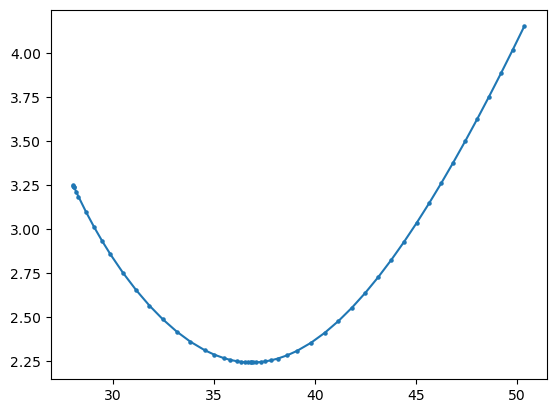

28.02692340037171 50.35262680109171 36.80403705233625 (2.2432137818383393+3.945063227585017e-05j)
1.8712450760000081
11 36.80403705233625 7.853981633974483 0.45344984105855446


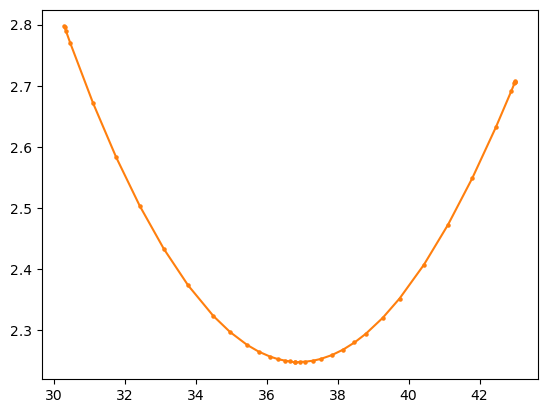

30.295127852873843 43.00691020342947 36.80403705233625 (2.247695254737706+5.473308519045375e-05j)
2.0292944819999974
12 36.80403705233625 7.853981633974483 0.7557497350975907


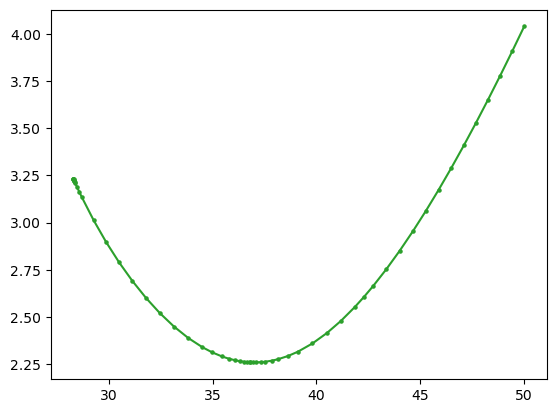

28.294606640549407 50.01027221676532 36.80403705233625 (2.258371553924772+6.145971323631559e-06j)
2.179404353999999
13 36.80403705233625 7.853981633974483 1.058049629136627


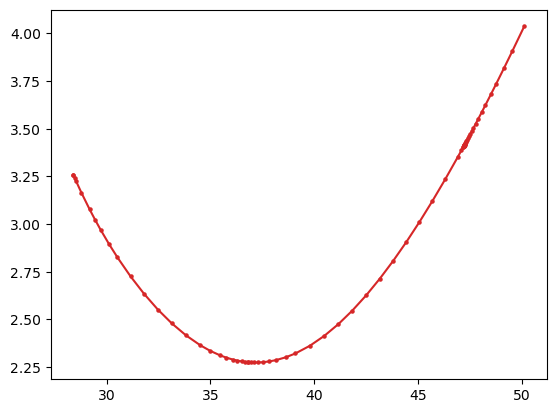

28.393599723989613 50.12837411105135 37.08767124067832 (2.274120101400733-0.0011913942638351058j)
2.3401030450000064
14 37.08767124067832 7.853981633974483 1.3603495231756633


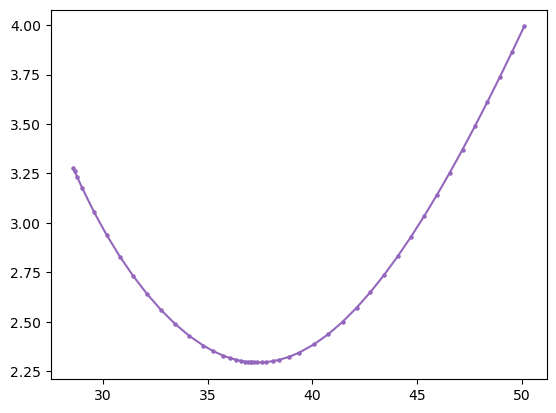

28.584608275916192 50.123146135133574 37.37149430352217 (2.294157432318469+0.0006894043480941223j)
2.5038430640000087
15 37.37149430352217 7.853981633974483 1.6626494172146995


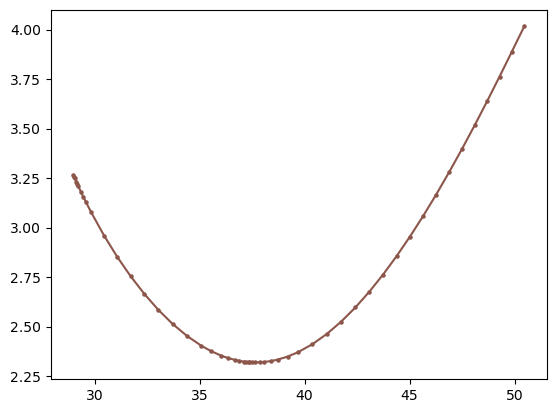

28.977795009478633 50.46060679390716 37.37149430352217 (2.318674531710819+1.4926367849319705e-05j)
2.6603951090000066
16 37.37149430352217 7.853981633974483 1.964949311253736


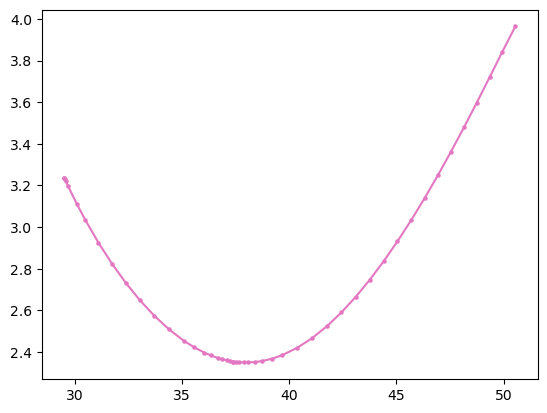

29.517460525416052 50.54062358806836 37.37149430352217 (2.3518555220757444-6.964884480148816e-05j)
2.839138407000007
17 37.37149430352217 7.853981633974483 2.267249205292772


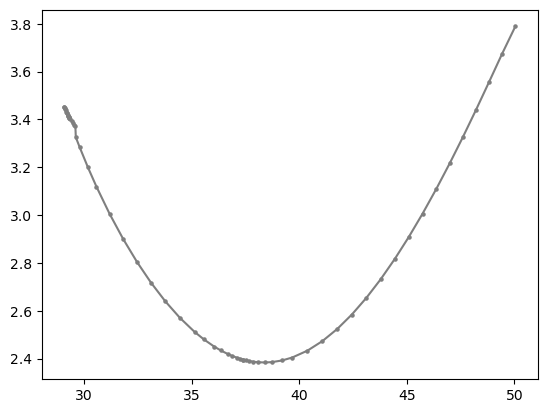

29.078414784915008 50.038799199453635 38.39807314583715 (2.3838173009683428-0.0033195461483359946j)
2.989037808000006
18 38.39807314583715 7.853981633974482 2.5695490993318084


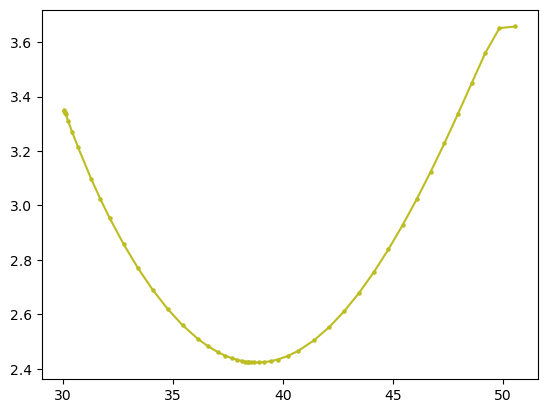

30.054427351112718 50.5504186695695 38.89314709696956 (2.423351753022871-0.000979924081016474j)
3.136384095000011
19 38.89314709696956 7.853981633974482 2.8718489933708446


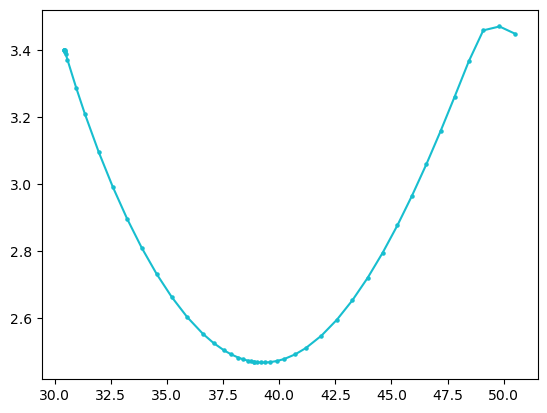

30.439109589042864 50.51219986168816 39.388528589441044 (2.4674738092251243-0.00044009659571742944j)
3.2909008150000005
20 39.388528589441044 7.853981633974482 3.174148887409881


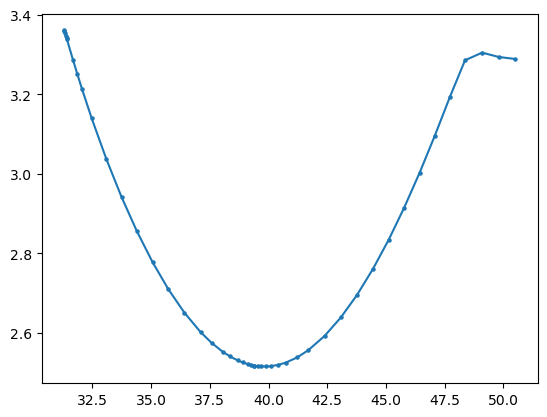

31.308361622072255 50.503680158989056 39.88475606041771 (2.516032901665619+8.6812817743272e-05j)
3.4443854990000062
21 39.88475606041771 7.853981633974482 3.4764487814489176


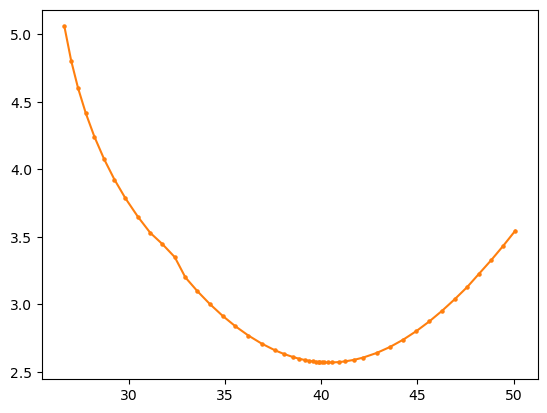

26.668803049609892 50.087277066117835 40.38064857828994 (2.569083974785692+0.00021190012032968087j)
3.5992882480000077
22 40.38064857828994 7.853981633974482 3.778748675487954


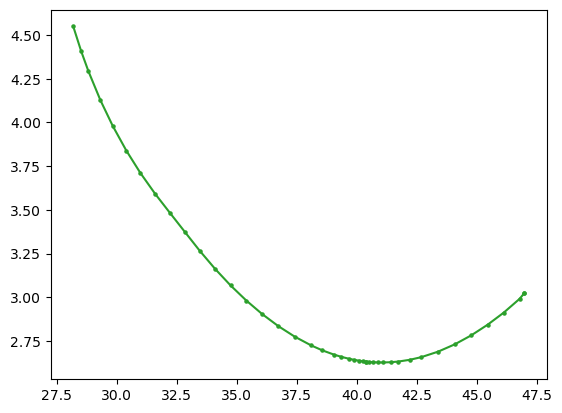

28.189643296976826 46.97086961674106 41.08883181507087 (2.626343078935541+3.0923059017861467e-06j)
3.7855682810000104
23 41.08883181507087 7.853981633974482 4.08104856952699


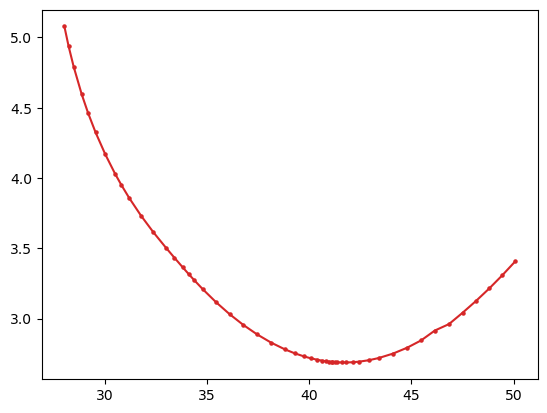

28.000481859778315 50.08460724744434 41.797373683421114 (2.687358128387653-0.0019313977046828525j)
3.9219131960000055
24 41.797373683421114 7.853981633974482 4.383348463566026


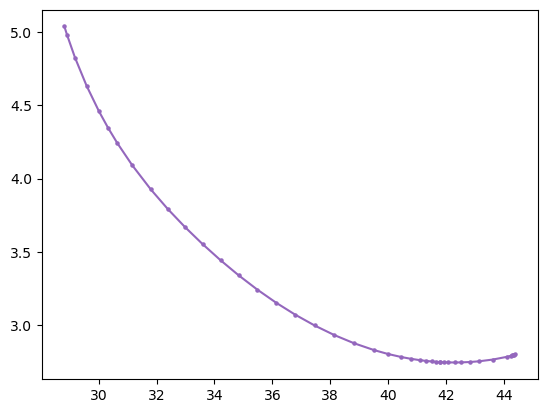

28.81564376421204 44.39137260641501 42.29235352684256 (2.747621006109314-9.907842032017141e-05j)
4.083495613000011
25 42.29235352684256 7.592182246175333 4.383348463566026


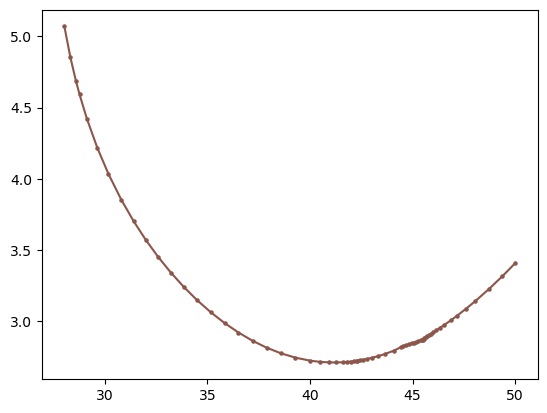

28.037808167740284 50.00045582827993 41.266855242003174 (2.7124991357001242-0.0010163773520371476j)
4.2087503550000065
26 41.266855242003174 7.330382858376184 4.232198516546508


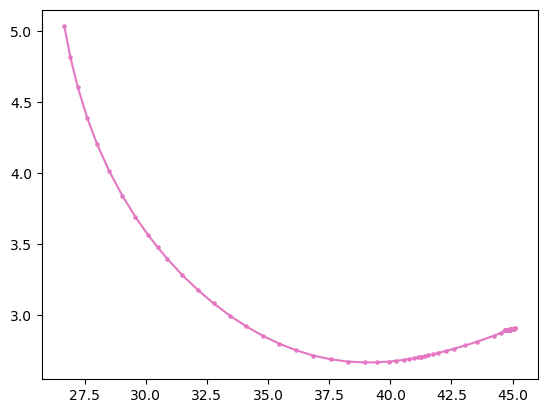

26.676398797722403 45.108504432672895 38.971332421397754 (2.6628117528171136+0.0004951009477977807j)
4.343148933000009
27 38.971332421397754 7.068583470577034 4.08104856952699


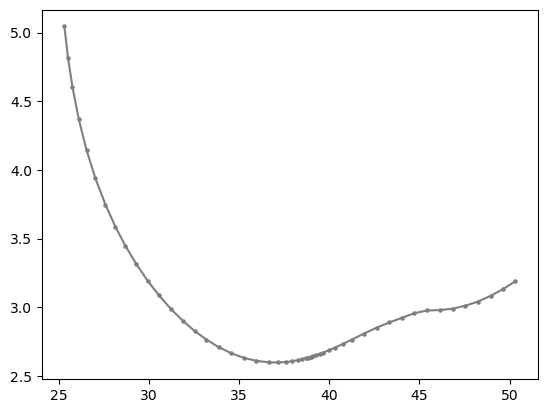

25.313951479516867 50.31510866394411 37.143450276302545 (2.598561472574573-0.0012846807099113576j)
4.4685633290000055
28 37.143450276302545 6.8067840827778845 3.929898622507472


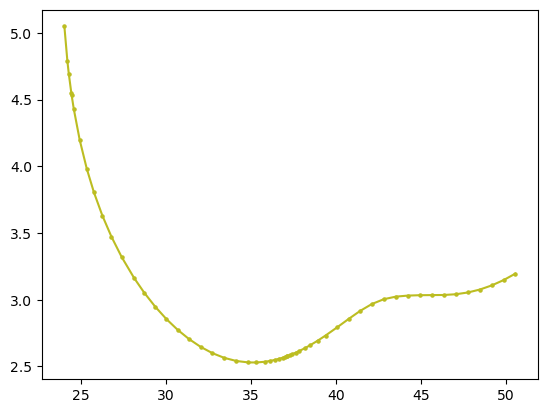

24.019849170914274 50.555265091973226 35.32481508230541 (2.5295859637267633+0.002318990431738208j)
4.607543801000006
29 35.32481508230541 6.544984694978735 3.778748675487954


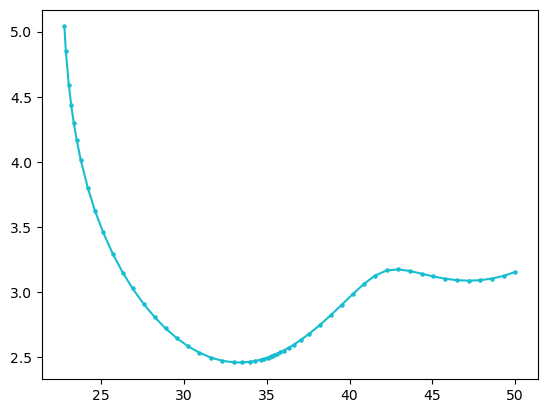

22.787287571695042 50.00005538324046 33.51054452196019 (2.4616699453332576-0.0010148625953800981j)
4.7382777580000095
30 33.51054452196019 6.283185307179586 3.6275987284684357


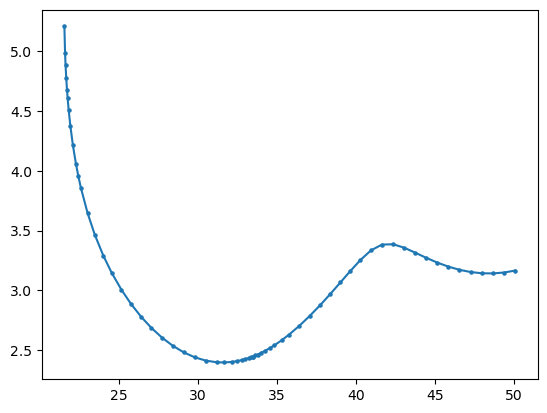

21.571640538268746 50.0893073611156 31.694125088491383 (2.397158435488038-0.0011392689401256493j)
4.867502965
31 31.694125088491383 6.021385919380436 3.4764487814489176


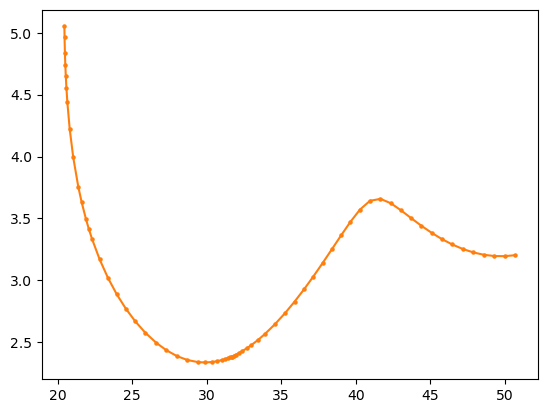

20.459192777996602 50.697311643219194 29.887122765510203 (2.3372351426123426-0.001823176053759564j)
5.003335200000009
0 51.555795723664914 4.984257575406883 0.0


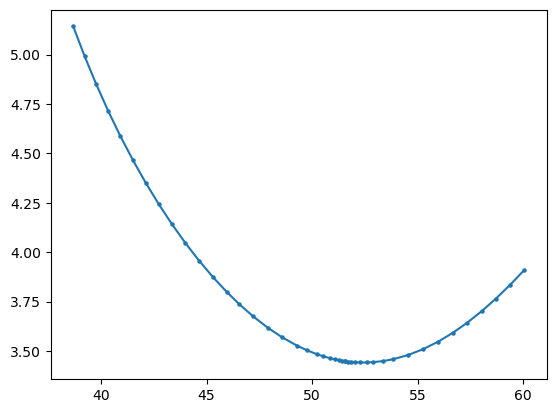

38.690061459694874 60.041387558574236 52.580954688662054 (3.4420087161710593-0.00022412578198806402j)
5.137721319000008
1 52.580954688662054 5.28633379209821 0.0


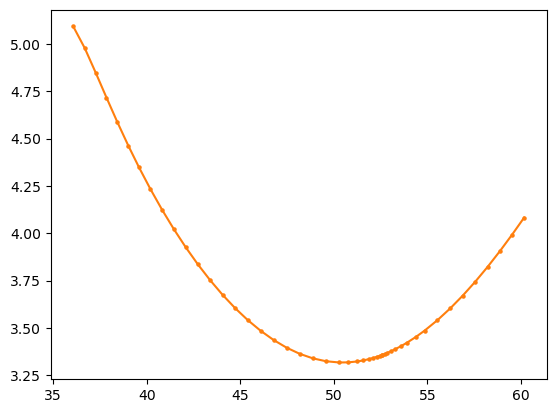

36.07328177041943 60.167467883561365 50.28498740288225 (3.317183797042332-0.00013058804408574553j)
5.288935834
2 50.28498740288225 5.588410008789536 0.0


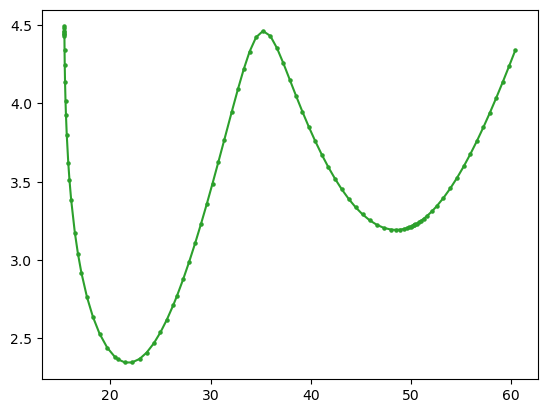

15.420848046600554 60.411494064130004 48.467080875426134 (3.193069484048215-0.00086771485658256j)
5.41763678800001
3 48.467080875426134 5.890486225480862 0.0


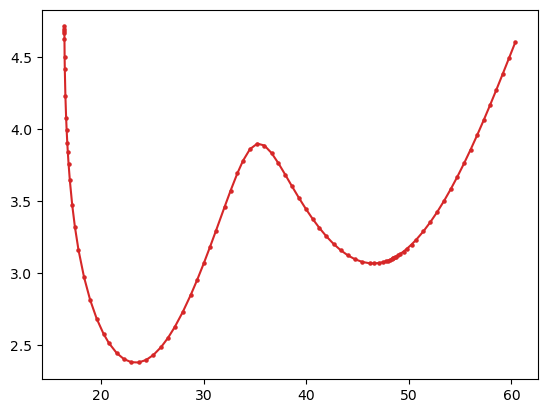

16.427868815775117 60.373994987732104 46.64709623422973 (3.0687089023526104-0.00018248004633182325j)
5.542047322000002
4 46.64709623422973 6.192562442172188 0.0


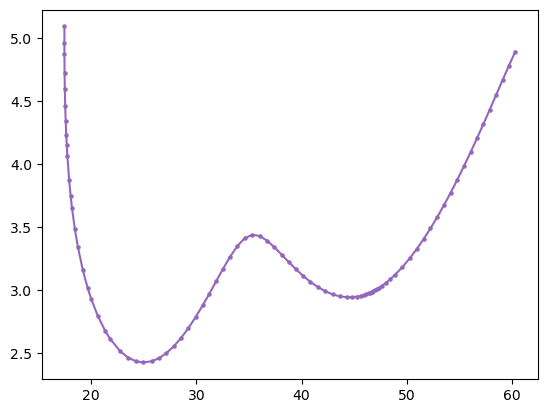

17.4594374121465 60.30660780788526 44.35339787024744 (2.940698552479061+0.0006041251233789739j)
5.670091601999999
5 44.35339787024744 6.494638658863514 0.0


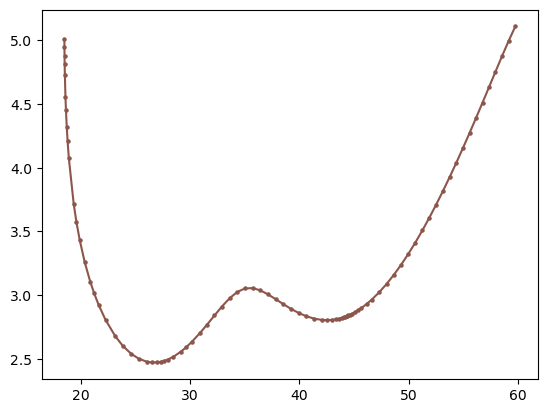

18.50979243190331 59.750472452989655 42.5357989385224 (2.8036184135499638-0.00025858733549968913j)
5.973865529999998
6 42.5357989385224 6.796714875554841 0.0


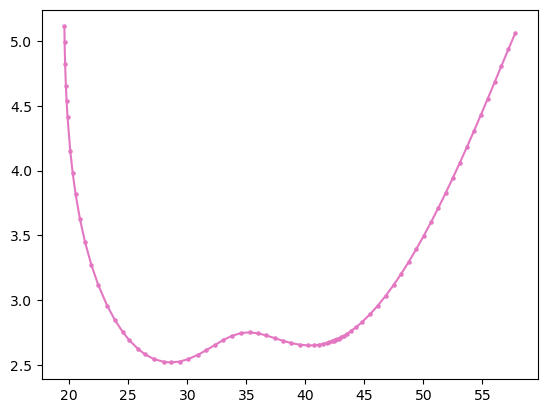

19.582058835300906 57.791906817607526 40.24005117173177 (2.650931095220046-0.0014181619916263655j)
6.19015497800001
7 40.24005117173177 7.0987910922461674 0.0


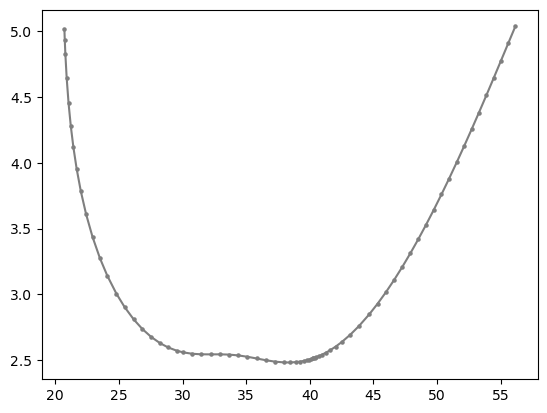

20.71177018651594 56.150316869621 38.41884495148134 (2.4815875112538928-0.0009465888268365881j)
6.339761012000011
8 38.41884495148134 7.400867308937493 0.0


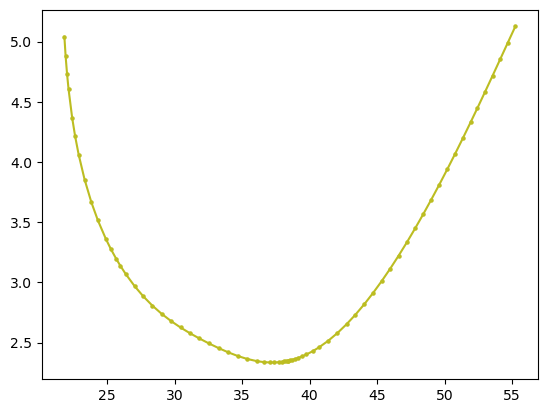

21.828576399845428 55.240642117136886 37.06087492297297 (2.3343218906071406-6.940337295785499e-05j)
6.524160671000004
9 37.06087492297297 7.702943525628819 0.0


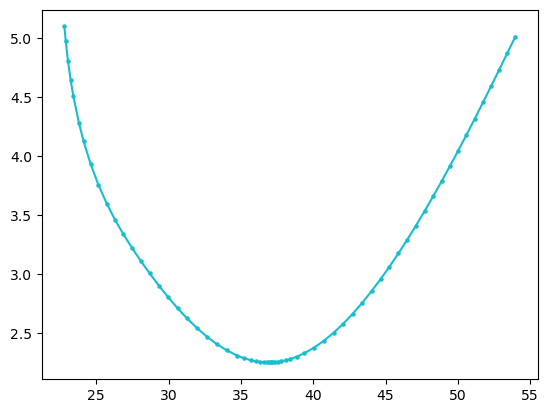

22.79359343557292 53.964941400529305 37.06087492297297 (2.252854018534159+1.6280837495476506e-05j)
6.674967993999999
10 37.06087492297297 7.853981633974483 0.15114994701951814


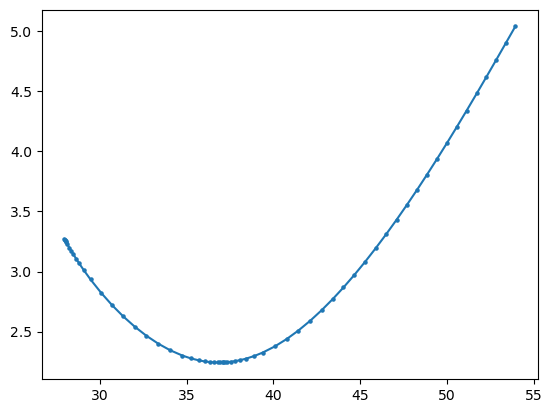

27.945033425100487 53.9421824632127 36.91930143369606 (2.243414702685736+8.59873219782135e-05j)
6.816144199000007
11 36.91930143369606 7.853981633974483 0.45344984105855446


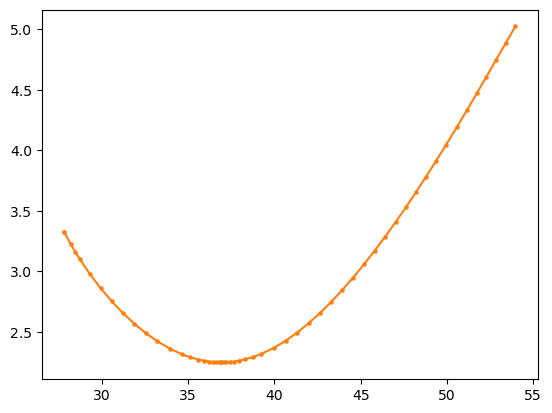

27.81917355421775 53.96304536778234 36.91930143369606 (2.247673753256528-9.744524831866255e-06j)
6.964915679000001
12 36.91930143369606 7.853981633974483 0.7557497350975907


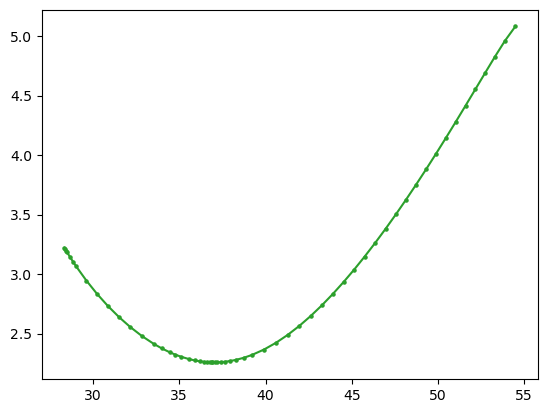

28.34145248588025 54.48035070790255 36.91930143369606 (2.2577442286003246-2.2230959430689527e-05j)
7.097223877000005
13 36.91930143369606 7.853981633974483 1.058049629136627


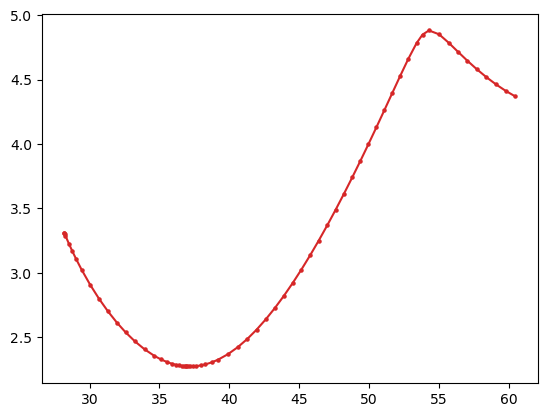

28.20152652975301 60.47628034184347 36.91930143369606 (2.273767740984311+3.8763004910149864e-05j)
7.243640483000007
14 36.91930143369606 7.853981633974483 1.3603495231756633


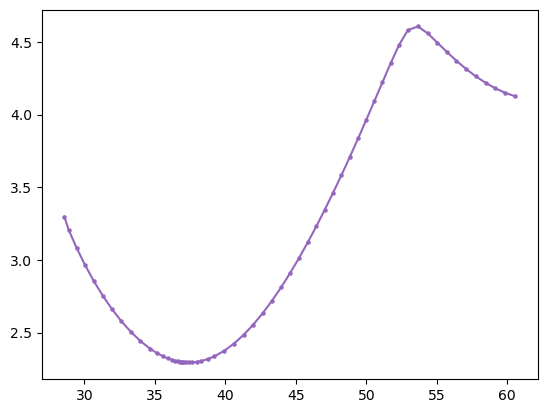

28.573514501771367 60.565914979128344 37.41529416500851 (2.2941468830446134-0.000894456153237604j)
7.400757682000005
15 37.41529416500851 7.853981633974483 1.6626494172146995


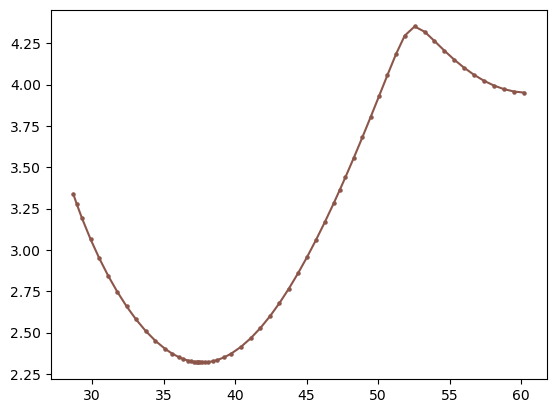

28.6813028571189 60.22212237971424 37.69872031916007 (2.3192156583495622+2.122538028662473e-05j)
7.5551696690000085
16 37.69872031916007 7.853981633974483 1.964949311253736


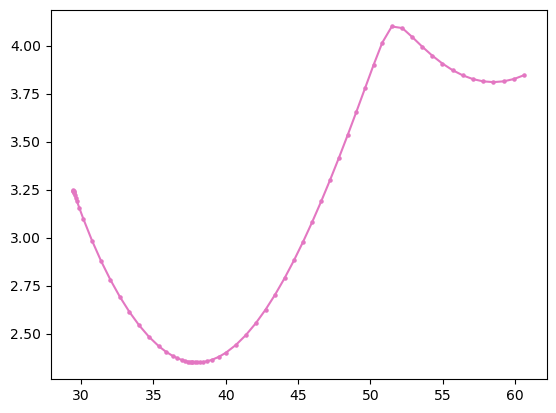

29.47047033895721 60.615503143838545 37.98985666978875 (2.349105230306965-0.00037656482442530864j)
7.7045246090000035
17 37.98985666978875 7.853981633974483 2.267249205292772


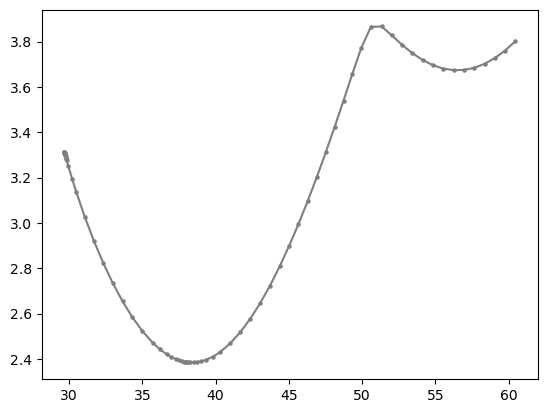

29.669153706895106 60.462244451254755 38.272811445881146 (2.3839305776528827-0.0001420939784932088j)
7.849625356000004
18 38.272811445881146 7.853981633974482 2.5695490993318084


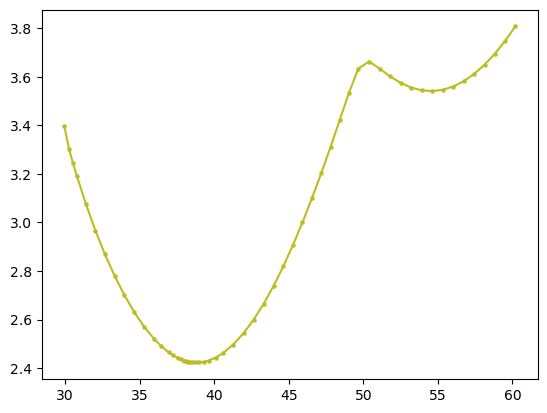

29.949883775348503 60.19430975040595 38.7679190023694 (2.4232821196972623-0.000501517800183213j)
8.026173391
19 38.7679190023694 7.853981633974482 2.8718489933708446


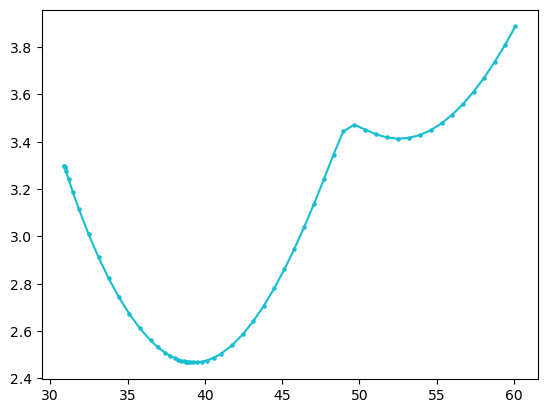

30.911430524436938 60.09011929863878 39.26389412568999 (2.4673618520142178-0.0006143336293903741j)
8.172474397000002
20 39.26389412568999 7.853981633974482 3.174148887409881


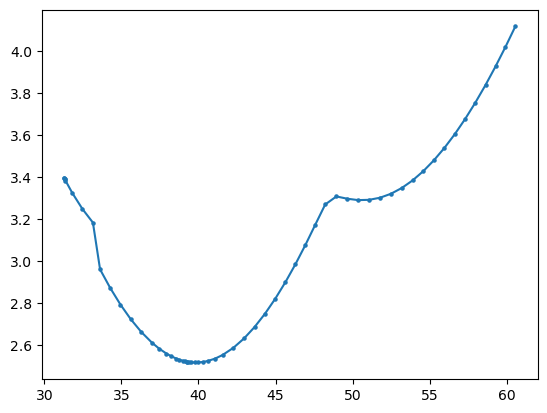

31.302641508794235 60.55704294211686 39.7589875749217 (2.5160631249140395-0.000981343877018266j)
8.323727430000005
21 39.7589875749217 7.853981633974482 3.4764487814489176


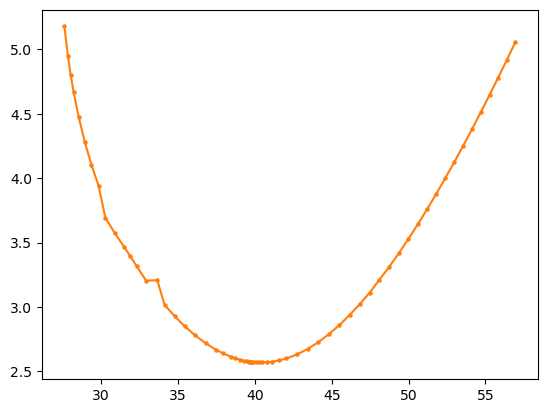

27.605584553173088 56.94490610988232 40.46648192091507 (2.569095211463382-0.0006476913750493667j)
8.461634672000002
22 40.46648192091507 7.853981633974482 3.778748675487954


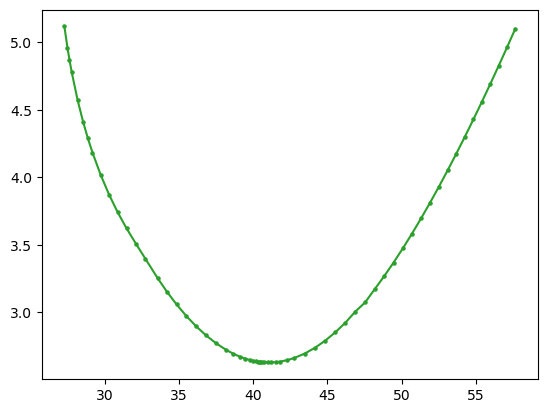

27.24747180007003 57.673541895896115 40.96298241040815 (2.626411489975354+0.0006211700663890939j)
8.626059869000002
23 40.96298241040815 7.853981633974482 4.08104856952699


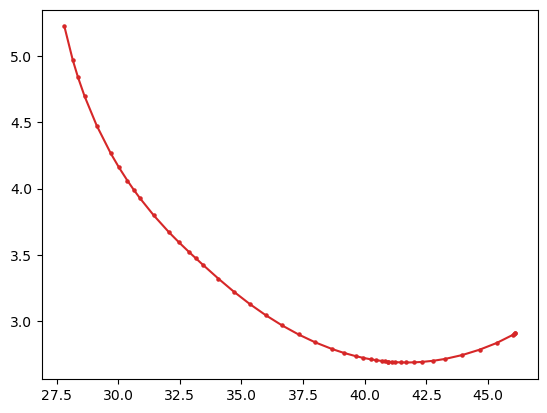

27.81524732444114 46.10816062855537 41.671145850384555 (2.6872811652229105+0.0004265119532898446j)
8.788870653000004
24 41.671145850384555 7.853981633974482 4.383348463566026


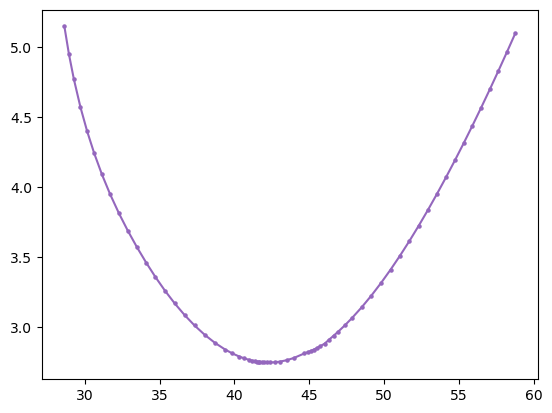

28.64998630489174 58.746533390704556 42.37927354849263 (2.7476992143472363+0.000813500272158548j)
8.939168612000003
25 42.37927354849263 7.592182246175333 4.383348463566026


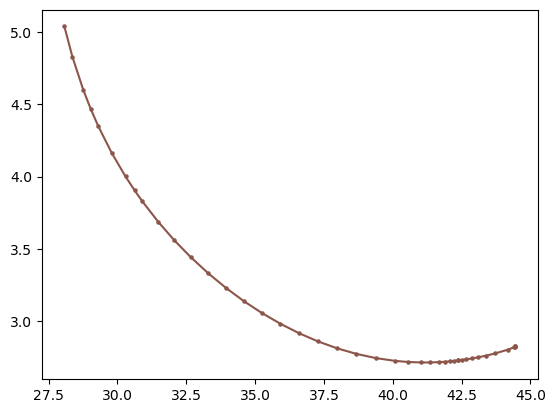

28.072556759913937 44.45062215538497 41.03573275045611 (2.7125636829078417+0.0004398086181356909j)
9.090152064000009
26 41.03573275045611 7.330382858376184 4.232198516546508


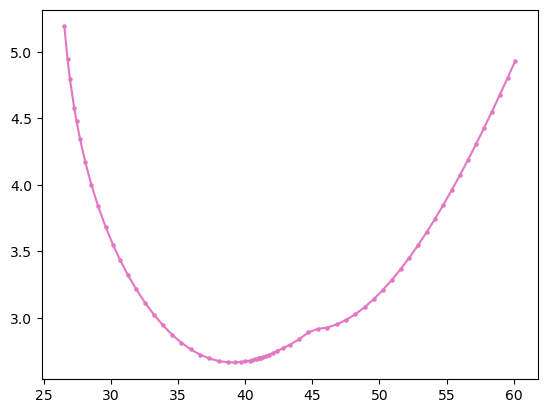

26.5336207535587 60.11895312115476 39.21498437589993 (2.6628654955559683+0.0016344106351853277j)
9.279655020000007
27 39.21498437589993 7.068583470577034 4.08104856952699


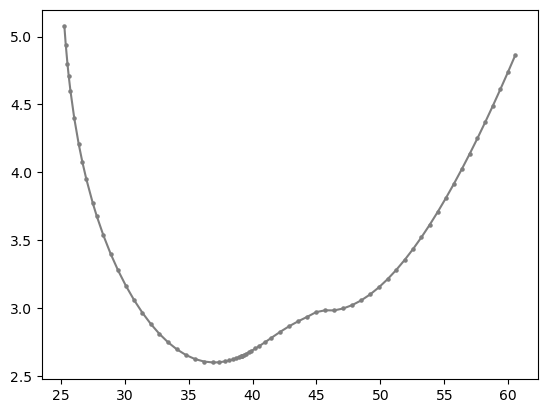

25.292159210416575 60.54305912124523 36.910637097064736 (2.598419306184279-0.0019088717359921608j)
9.474324146
28 36.910637097064736 6.8067840827778845 3.929898622507472


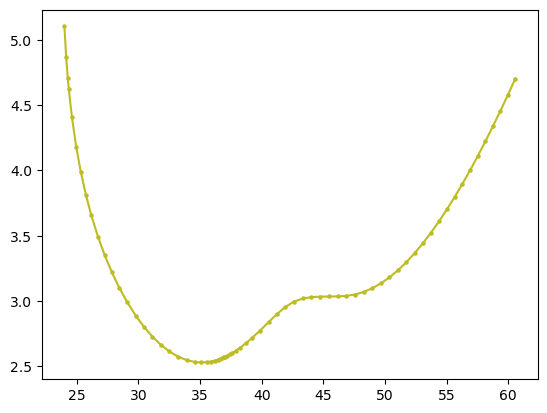

23.99147531916609 60.57376975042823 35.093009634708416 (2.5290643002134834+0.0006233986831669879j)
9.637360092000009
29 35.093009634708416 6.544984694978735 3.778748675487954


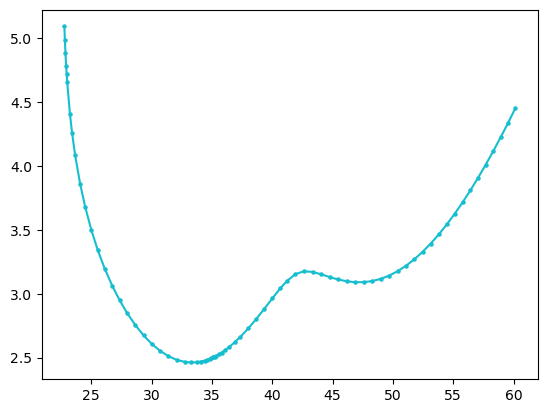

22.767917336357787 60.14196181997627 33.27775014416595 (2.461240347311969+0.0031893809494686755j)
9.790774718000009
30 33.27775014416595 6.283185307179586 3.6275987284684357


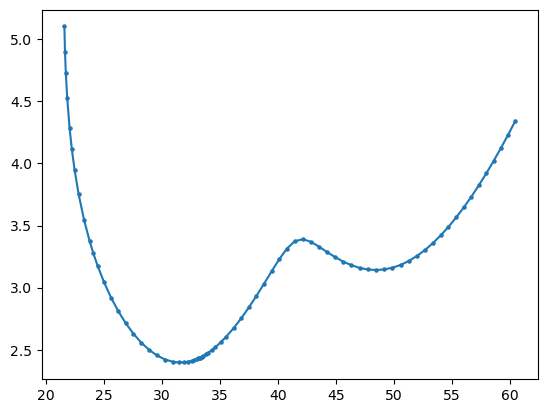

21.58755408159573 60.452566129730265 31.457833507004537 (2.3971676134129134-0.0021369602490998517j)
9.94741241300001
31 31.457833507004537 6.021385919380436 3.4764487814489176


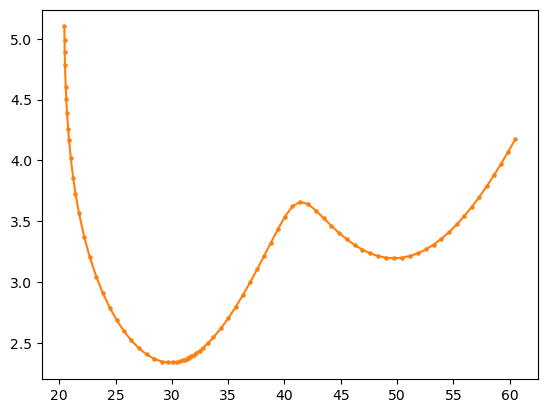

20.45513908302454 60.49692247627738 29.640118389766315 (2.337986883508466+0.00184409947947901j)
10.093459412000001


In [13]:
start=timeit.default_timer()
adssweep=[]
freqsweep=[]
vssweep=[]
wssweep=[]
dirsweep=[]
dssweep=[]
argsdict['verbose']=0
argsdict['lambdamax']=admax

ds=5E-1
ds0=1E-1
argsdict['dsmax']=ds
argsdict['ds']=ds0
argsdict['dsmin']=1E-8

argsdict['epsu']=1E-2
argsdict['epsl']=1E-2
argsdict['dmu_fd']=1E-4
argsdict['epstp']=5E-1
argsdict['epdir']=1E-3
argsdict['thmu']=5E-1
argsdict['thl']=5E0
argsdict['thu']=1E-4

argsdict['itmax']=10
argsdict['Nsteps']=5000

print(ks)
print(len(ks))
load=True
overwrite=True

l=0

for j in range(2):
    ad0=ad0s[j]
    vs0=vn0s[j]
    ws0=wn0s[j]
    freq0=freq0s[j]
    
    argsdict['freq']=freq0
    argsdict['kx']=ks[0][0]
    argsdict['ky']=ks[0][1]
    
    lps,ls,mps,ms,nps,ns=viscid.makeindices(argsdict)
    kappax = (argsdict['kx'] + argsdict['k1x']*ms + argsdict['k2x']*ns)
    kappay = (argsdict['ky'] + argsdict['k1y']*ms + argsdict['k2y']*ns)
    kappa = (kappax**2+kappay**2)**0.5
    kappapx = (argsdict['kx'] + argsdict['k1x']*mps + argsdict['k2x']*nps)
    kappapy = (argsdict['ky'] + argsdict['k1y']*mps + argsdict['k2y']*nps)
    S = (- np.exp(-kappa*argsdict['h0']) * iv(ms-mps, kappa*argsdict['As']*0.5) * iv(ns-nps, kappa*argsdict['As']*0.5) + np.exp(kappa*argsdict['h0']) * iv(ms-mps, -kappa*argsdict['As']*0.5) * iv(ns-nps, -kappa*argsdict['As']*0.5))
    C = (np.exp(-kappa*argsdict['h0']) * iv(ms-mps, kappa*argsdict['As']*0.5) * iv(ns-nps, kappa*argsdict['As']*0.5) + np.exp(kappa*argsdict['h0']) * iv(ms-mps, -kappa*argsdict['As']*0.5) * iv(ns-nps, -kappa*argsdict['As']*0.5))

    #right preconditioner
    shape_flat=((2*argsdict['Nx']+1)*(2*argsdict['Ny']+1),(2*argsdict['Nx']+1)*(2*argsdict['Ny']+1))
    shape2=((2*argsdict['Nx']+1),(2*argsdict['Ny']+1),(2*argsdict['Nx']+1),(2*argsdict['Ny']+1))
    A2=argsdict['g']*(argsdict['rho']**2*(kappax*kappapx+kappay*kappapy)/kappa*C)
    argsdict['preconditioner']=np.linalg.pinv(A2.reshape(shape_flat)).reshape(shape2)

    argsdict['precondition_axes']=((6,7),(0,1))
    argsdict['precondition_order']=(0,1,2,3,4,5,6,7)

    for i in range(len(ks)):
        kx=ks[i][0]
        ky=ks[i][1]
        print(i,freq0,kx,ky)
        if not os.path.exists('data/experiment/%iads.npy'%(l)) or not load:
            argsdict['freq']=freq0
            if(argsdict['kx']!=kx):
                argsdict['par']='kx'
                argsdict['pari']=np.min([kx,argsdict['kx']])
                argsdict['parf']=np.max([kx,argsdict['kx']])

                argsdict['ds']=np.sign(kx-argsdict['kx'])*1E-4
                ads1,vs1,ws1,pars1,dirs1,dss1=viscid.pseudocont(ad0, vs0, ws0, mat, argsdict, mat2)
                argsdict['kx']=kx
                ads1,vs1,ws1=viscid.rayleigh_mat(ads1[-1], vs1[-1], ws1[-1], mat, argsdict, mat2)
                ad0=ads1[-1]
                vs0=vs1[-1]
                ws0=ws1[-1]
            if(argsdict['ky']!=ky):
                argsdict['par']='ky'
                argsdict['pari']=np.min([ky,argsdict['ky']])
                argsdict['parf']=np.max([ky,argsdict['ky']])

                argsdict['ds']=np.sign(ky-argsdict['ky'])*1E-4
                ads1,vs1,ws1,pars1,dirs1,dss1=viscid.pseudocont(ad0, vs0, ws0, mat, argsdict, mat2)
                argsdict['ky']=ky
                ads1,vs1,ws1=viscid.rayleigh_mat(ads1[-1], vs1[-1], ws1[-1], mat, argsdict, mat2)
                ad0=ads1[-1]
                vs0=vs1[-1]
                ws0=ws1[-1]

            lps,ls,mps,ms,nps,ns=viscid.makeindices(argsdict)
            kappax = (argsdict['kx'] + argsdict['k1x']*ms + argsdict['k2x']*ns)
            kappay = (argsdict['ky'] + argsdict['k1y']*ms + argsdict['k2y']*ns)
            kappa = (kappax**2+kappay**2)**0.5
            kappapx = (argsdict['kx'] + argsdict['k1x']*mps + argsdict['k2x']*nps)
            kappapy = (argsdict['ky'] + argsdict['k1y']*mps + argsdict['k2y']*nps)
            S = (- np.exp(-kappa*argsdict['h0']) * iv(ms-mps, kappa*argsdict['As']*0.5) * iv(ns-nps, kappa*argsdict['As']*0.5) + np.exp(kappa*argsdict['h0']) * iv(ms-mps, -kappa*argsdict['As']*0.5) * iv(ns-nps, -kappa*argsdict['As']*0.5))
            C = (np.exp(-kappa*argsdict['h0']) * iv(ms-mps, kappa*argsdict['As']*0.5) * iv(ns-nps, kappa*argsdict['As']*0.5) + np.exp(kappa*argsdict['h0']) * iv(ms-mps, -kappa*argsdict['As']*0.5) * iv(ns-nps, -kappa*argsdict['As']*0.5))

            #right preconditioner
            shape_flat=((2*argsdict['Nx']+1)*(2*argsdict['Ny']+1),(2*argsdict['Nx']+1)*(2*argsdict['Ny']+1))
            shape2=((2*argsdict['Nx']+1),(2*argsdict['Ny']+1),(2*argsdict['Nx']+1),(2*argsdict['Ny']+1))
            A2=argsdict['g']*(argsdict['rho']**2*(kappax*kappapx+kappay*kappapy)/kappa*C)
            argsdict['preconditioner']=np.linalg.pinv(A2.reshape(shape_flat)).reshape(shape2)

            argsdict['precondition_axes']=((6,7),(0,1))
            argsdict['precondition_order']=(0,1,2,3,4,5,6,7)

            argsdict['freq']=freq0
            argsdict['par']='freq'
            argsdict['pari']=minfreq
            argsdict['parf']=maxfreq

            argsdict['ds']=ds0
            ads2,vs2,ws2,pars2,dirs2,dss2=viscid.pseudocont(ad0, vs0, ws0, mat, argsdict, mat2, real=1)
            argsdict['freq']=freq0        
            argsdict['ds']=-ds0
            ads3,vs3,ws3,pars3,dirs3,dss3=viscid.pseudocont(ad0, vs0, ws0, mat, argsdict, mat2, real=1) 
            

            freqsweep=freqsweep+[np.flip(pars3).tolist()+pars2]
            adssweep=adssweep+[np.flip(ads3).tolist()+ads2]
            vssweep=vssweep+[np.flip(vs3,axis=0).tolist()+vs2]
            wssweep=wssweep+[np.flip(ws3,axis=0).tolist()+ws2]
            dirsweep=dirsweep+[np.flip(dirs3,axis=0).tolist()+dirs2]
            dssweep=dssweep+[np.flip(dss3,axis=0).tolist()+dss2]
            if overwrite:
                np.save('data/experiment/%iads.npy'%(l),adssweep[l])
                np.save('data/experiment/%ivs.npy'%(l),vssweep[l])
                np.save('data/experiment/%iws.npy'%(l),wssweep[l])
                np.save('data/experiment/%ifreqs.npy'%(l),freqsweep[l])
                np.save('data/experiment/%idirs.npy'%(l),dirsweep[l])
                np.save('data/experiment/%idss.npy'%(l),dssweep[l])

        else:
            adssweep=adssweep+[np.load('data/experiment/%iads.npy'%(l))]
            freqsweep=freqsweep+[np.load('data/experiment/%ifreqs.npy'%(l))]
            argsdict['kx']=kx
            argsdict['ky']=ky

        plt.plot(freqsweep[l],np.abs(np.real(adssweep[l])),c=colors[i%len(colors)])
        plt.scatter(freqsweep[l],np.abs(np.real(adssweep[l])),c=colors[i%len(colors)],s=5)
        plt.show() 
            
        peaks,pprop=find_peaks(-np.abs(adssweep[-1]))
        ind=peaks[np.argmin(np.abs(np.array(freqsweep[-1])[peaks]-freq0))]
        ad0=adssweep[-1][ind]
        if vssweep != []:
            vs0=np.array(vssweep[-1][ind])
            ws0=np.array(wssweep[-1][ind])
        freq0=freqsweep[-1][ind]
        print(freqsweep[-1][0],freqsweep[-1][-1],freq0,ad0)
        
        l=l+1

        stop=timeit.default_timer()
        print(stop-start)

In [14]:
adssweep=[np.load('data/experiment/%iads.npy'%(i)) for i in range(2*len(ks))]
freqsweep=[np.load('data/experiment/%ifreqs.npy'%(i)) for i in range(2*len(ks))]

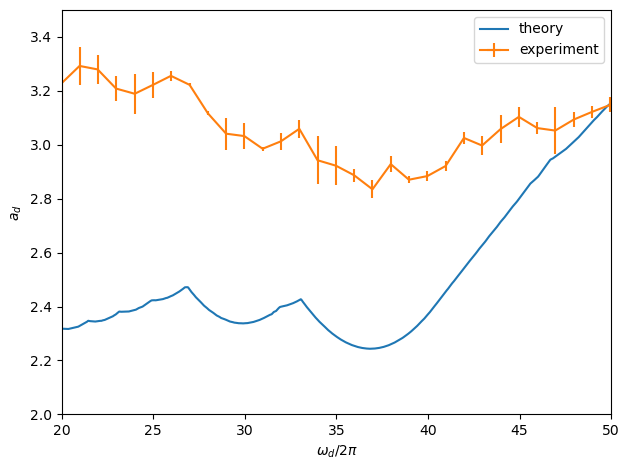

In [17]:
plotfreqs=20+(50-20)*np.arange(1000)/1000
acs=[]
for i in range(2*len(ks)):
    f=interp1d(np.array(freqsweep[i]),np.real(adssweep[i]))
    inds=np.intersect1d(np.where(plotfreqs<np.max(freqsweep[i]))[0],np.where(plotfreqs>np.min(freqsweep[i]))[0])
    ac=np.ones(len(plotfreqs))*np.inf
    ac[inds]=f(plotfreqs[inds])
    acs=acs+[ac]
plt.plot(plotfreqs,np.min(np.array(acs),axis=0),label='theory')
plt.xlabel(r'$\omega_d/2\pi$')
plt.ylabel(r'$a_d$')
plt.ylim(0,20.0)
plt.tight_layout()
filebases=['data/experiment/new_20_50/new_20_50','data/experiment/new_20_50_2/new_20_50_2','data/experiment/new_20_50_3/new_20_50_3']
dats=[]
for filebase in filebases:
    dat=np.loadtxt('%s.txt'%(filebase))
    order=np.argsort(dat[:,2])
    dats=dats+[dat[order]]
x,y=np.mean(np.array(dats)[:,:,[2,1]],axis=0).T
xerr,yerr=np.std(np.array(dats)[:,:,[2,1]],axis=0).T
plt.errorbar(x,y,xerr=xerr,yerr=yerr,label='experiment')
plt.xlabel(r'$\omega_d/2\pi$')
plt.ylabel(r'$a_d$')
plt.xlim(20,50)
plt.ylim(2,3.5)
plt.tight_layout()
plt.legend()
plt.savefig('plots/experiment.pdf')
plt.show()

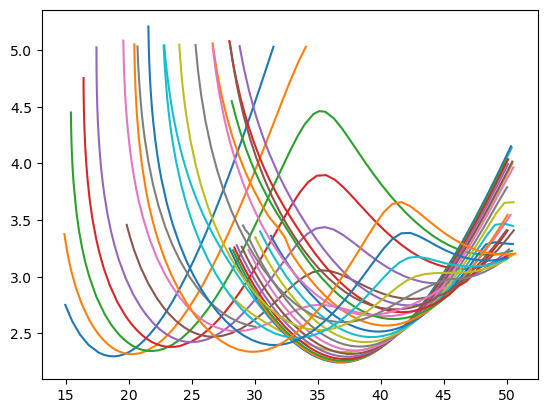

In [16]:
for i in range(len(ks)):
    plt.plot(freqsweep[i],np.abs(np.real(adssweep[i])),c=colors[(i)%len(colors)])
